Section 2: Direction Vectors

Explanation: We defined altaz_to_unit_vector function that takes azimuth and altitude of a point(int degrees) as its parameters. Using numpy functions we first converted these values to radians. Then we used the formulas for unit vector given under section 1.2 to find the x,y and z components. We assume these to be in meters. Finally our function returns an array which stores the coordinates of our unit vector. To plot the unit vector we used the quiver function of matplotlib to generate an arrow from origin to that point. According to ENU Coordinate System X axis represents East, Y axis North and Z axis Up.

In [17]:
import numpy as np
import matplotlib.pyplot as plt
def altaz_to_unit_vector(Az, Alt):
    alt=np.radians(Alt)
    az=np.radians(Az)
    x=np.cos(alt)*np.sin(az)
    y=np.cos(alt)*np.cos(az)
    z=np.sin(alt)
    s=np.array([x,y,z])                           #An array containing the coordinates of our point (This array represents our unit vector)
    return s
def plot(s):
    fig=plt.figure()
    ax=plt.axes(projection='3d')
    ax.set_xlim([-3, 3])                          #Setting limits for axes
    ax.set_ylim([-3, 3])
    ax.set_zlim([-3, 3])
    ax.set_xlabel("East(meters)")                        
    ax.set_ylabel("North(meters)")                         
    ax.set_zlabel("Up(meters)")
    ax.quiver(0,0,0,s[0],s[1],s[2])               #Using quiver to create vectors from origin to our point 
    plt.savefig("figures/cs1.png")
    plt.show()

Plotting three sets of Az-Alt:

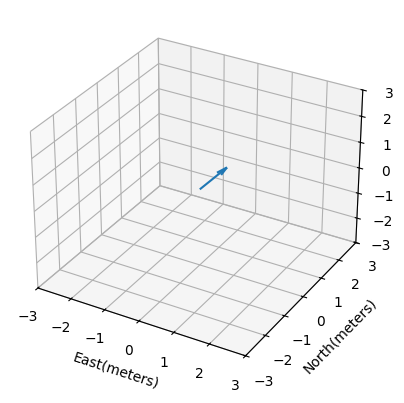

In [12]:
v1=altaz_to_unit_vector(45,45)
plot(v1)

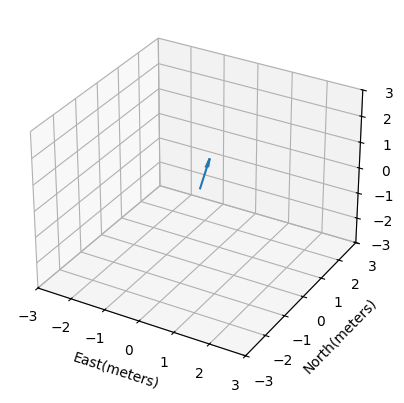

In [14]:
v2=altaz_to_unit_vector(0,60)
plot(v2)

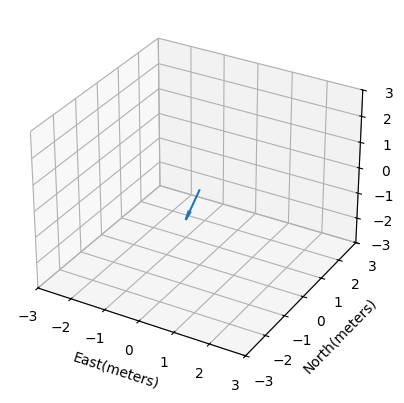

In [16]:
v3=altaz_to_unit_vector(180,-45)
plot(v3)

Section 3 : Two–Antenna TDOA Localization

Explanation: We assumed true FRB direction as azimuth=45 degrees and altitude=45 degrees. Since position of the telescopes is not given specifically we assumed one to be at origin and other at 15000m East.We took telescope at origin as reference to calculate b10. We calculated b10=r1-r0 as givenin section1.3 and then calculated time delay (named tdoa in our code). Then to generate gaussian noise we used np.random.normal function which generates a gaussian(normal) distribution. loc or mean is the value where this distribution is centered and scale is the standard deviation. So since ideally noise is 0 so we generated noise centered at 0 with standard deviation 10 micro seconds as given. So this function each time gives a noise from the gaussian distribution of noises. If we specify size parameter of this fucntion we can get many gaussian noises. Here we need only one value of noise. Then we added this gaussian noise to our tdoa.

In [19]:
true_alt=45             #True FRB altitude in degrees
true_az=45              #True FRB azimuth in degrees
s=altaz_to_unit_vector(true_az,true_alt)          #Position vector of FRB 
tel0=np.array([0,0,0])          #Position vector of first telescope
tel1=np.array([15000,0,0])      #Position vector of second telescope
b10=tel1-tel0   
c=3e8              #Speed of Light
tdoa=(np.dot(b10,s)/c)          
sigma_t= 10e-6             #Standard deviation                            
noise=np.random.normal(loc=0, scale=sigma_t)  #Using this function of generating gaussian distribution to generate gaussian noise
tdoa_act=tdoa+noise
print("tdoa(microseconds)=",tdoa/1e-6)
print("tdoa_actual(microseconds)=",tdoa_act/1e-6)
print("noise(microseconds)=",noise/1e-6)

tdoa(microseconds)= 25.000000000000004
tdoa_actual(microseconds)= 19.26523369277094
noise(microseconds)= -5.7347663072290604


We tried using astropy for assigning units to variables but doing so resulted in problems with random.normal function and while calculating X2 values. So we decided not to assign values at all to avoid complications.

We first make altitude and azimuth grids using arange function. We take grid gap of 0.1 degress to incoroprate approximately all points of 3d space. Then we make a 2d array to store X2 values for all the alt-az points in our grids. We use loops to first get the unit vector s for each az-alt point then find time delay and X2 value using the function given under section 1.5. Then we find the minimum X2 value using min function. Then we suntract X2min from X2 of each point and store it in another 2d array named delatX2. Now we use meshgrid to make a meshgrid using our altitude and azimuth grids. Then we use contour plot to plot deltaX2 against altitude and azimuth. We set tge level as 2.3 to get the required 1 sigma curve.

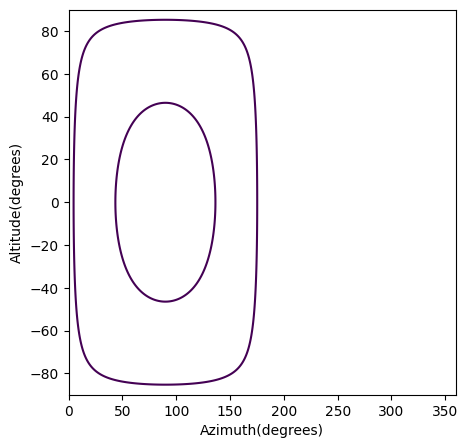

In [20]:
alt_grid=np.arange(-90, 90, 0.1)      #Making Altitude and Azimuth grids
az_grid= np.arange(0, 360, 0.1)
N_alt=alt_grid.size
N_az= az_grid.size
X2= np.zeros((N_alt, N_az))            #Making a 2D array to store X2 values for each point in the grid
for i, alt in enumerate(alt_grid):
    for j, az in enumerate(az_grid):
        s= altaz_to_unit_vector(az,alt)                
        tdoa_pred=(np.dot(b10, s)/c)
        X2[i, j]=((tdoa_pred - tdoa_act) ** 2) / (sigma_t ** 2)
X2min=X2.min()
deltaX2=X2-X2min            
AZ,ALT= np.meshgrid(az_grid, alt_grid)              #Using meshgrid and contour plots to plot the 1 sigma curve
plt.figure(figsize=(5,5))
x= plt.contour(AZ, ALT, deltaX2, levels=[2.3])   
plt.xlabel("Azimuth(degrees)")
plt.ylabel("Altitude(degrees)")
plt.xlim(0,360)
plt.ylim(-90,90)
plt.savefig("figures/2antenna.png")
plt.show()

Section 4: Three–Antenna Localization

Explanation: We took first telescope to be at origin, second at 15000m East and one at 15000m North. We took the telescope at origin as reference to calculate b10 and b20. Again we take true azimuth and altitude of frb as 45 degrees. We took same procedure as section 3 to calculate time delays, noise , actual time delays. Finally for X2 we added X2 of telescope 2 wrt 1 and that of telescope 3 wrt 1 as per the formula. Then found X2 min and found delta X2.

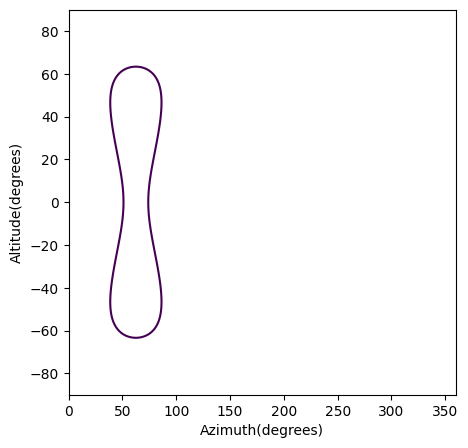

In [21]:
true_alt=45           #FRB altitude
true_az=45            #FRB azimuth
tel0=np.array([0,0,0])         #Position vector of first telescope 
tel1=np.array([15000,0,0])     #Position vector of second telescope 
tel2=np.array([0,15000,0])     #Position vector of third telescope 
b10=tel1-tel0
b20=tel2-tel0
c=3e8            #Speed of Light
s=altaz_to_unit_vector(true_az,true_alt)         #FRB position vector
tdoa1=np.dot(b10,s)/c           #Time delay for telescope 1
sigma_t=10e-6                   #Standard deviation for gaussian noise                                 
noise=np.random.normal(loc=0, scale=sigma_t)      #Gaussian noise 
tdoa1_act=tdoa1 + noise
tdoa2=np.dot(b20,s)/c           #Time delay for telescope 2                                               
noise=np.random.normal(loc=0, scale=sigma_t)        #Gaussian noise
tdoa2_act=tdoa2 + noise
alt_grid=np.arange(-90, 90, 0.1)  #Altitude Azimuth grids    
az_grid=np.arange(0, 360, 0.1)
N_alt=alt_grid.size
N_az=az_grid.size
X2=np.zeros((N_alt, N_az))        #2d array for X2 values at each point in the alt-az grid
for i,alt in enumerate(alt_grid):
    for j,az in enumerate(az_grid):
        s= altaz_to_unit_vector(az ,alt)                
        tdoa1_pred=np.dot(b10, s)/c  
        tdoa2_pred= np.dot(b20, s)/c 
        X2[i,j]= ((tdoa1_pred- tdoa1_act)**2)/(sigma_t**2) + ((tdoa2_pred- tdoa2_act)**2) /(sigma_t**2)
X2min=X2.min()
deltaX2=X2-X2min
AZ, ALT= np.meshgrid(az_grid, alt_grid)     #Using meshgrid and contour plots to plot deltaX2 where it is equal to 2.3
plt.figure(figsize=(5,5))
x= plt.contour(AZ, ALT,deltaX2,levels=[2.3])       
plt.xlabel("Azimuth(degrees)")
plt.ylabel("Altitude(degrees)")
plt.xlim(0,360)
plt.ylim(-90,90)
plt.savefig("figures/3antenna.png")
plt.show()

We use dA=Cos(alt)daltdaz to find the localization area. As total area is integration of dA which is repeated summation. We sum up dA for each point inside our 1 sigma curve. First we take a 2d array delatX2_ which is just a copy of deltaX2 then we set it to 0 for all points outside the curve i.e. deltaX2_>2.3 and 1 inside the curve. Then we sum up Cos(alt)dazdalt*deltaX2_ . Since we took a small gap of 0.1 in altitude and azimuth grid this method approximately gives us the desired area. Hence 0.1 becomes the value of daz and dlat.

In [8]:
deltaX2_=deltaX2.copy()
deltaX2_[deltaX2_<=2.3]=1
deltaX2_[deltaX2_>2.3]=0
dalt=0.5
daz=0.5
area=0
for i,alt in enumerate(alt_grid):
    for j,az in enumerate(az_grid):
        alt_rad=np.radians(alt)
        area=area+(np.cos(alt_rad)*dalt*daz*deltaX2_[i,j])
print("Localization Area(meter square)=",area)

Localization Area(meter square)= 55977.75990947561


Section 5: Localization as a Function of Sky Position

Explanation: We used healpy for this section which enabled us to convert the sky into pixels of equal areas. We set the nside parameter to 64 which would divide the sky into 49,152 pixels. We then used similar approach to previous sections. First we took FRB altitude and azimuth grids, made a 2D Area array to store localization areas for each frb altitude and azimuth point. Then we looped over frb altiudes and azimuths, got s unit vector for the point, found true tdoas, added gaussian noise. Then we created a X square array to store X2 values for each pixel point. Then to get these X2 values we looped over the pixel points, got the unit vector of each pixel, found predicted tdoas then got the X2 values. Then by subtracting minimum X2 from each X2 values we got delta X2 values. Now for localization areas we summed up the number of pixels where delta X2<=2.3 and then multiplied it to the area of one pixel. Then we add each area to the 2D Area array.

In [22]:
import healpy as hp
import math 
nside = 64                             #setting nside parameter to 64 to good number of sky pixels
npix = hp.nside2npix(nside)             #This vairable stores the number of pixels generated  
pix_area_deg2 = hp.nside2pixarea(nside, degrees = True)          #Using this function for area of a pixel in degrees square
frb_alt = np.arange(20, 85, 1)      #FRB altutide and azimuth grids
frb_az  = np.arange(0, 360, 10)
sigma_t = 10e-6                #Standard deviation for noise in tdoa
Area= np.zeros((frb_alt.size,frb_az.size))     #A 2D array to store localization area for required altitudes and azimuths
log_Area=np.zeros((frb_alt.size,frb_az.size))
m = 0
for i,true_alt in enumerate(frb_alt):
    for j,true_az in enumerate(frb_az):
        s = altaz_to_unit_vector(true_az, true_alt)
        tdoa1_true = np.dot(b10, s) / c
        tdoa2_true = np.dot(b20, s) / c
        tdoa1_act = tdoa1_true + np.random.normal(0, sigma_t)     #random.normal function to generate gaussian error
        tdoa2_act = tdoa2_true + np.random.normal(0, sigma_t)
        X2 = np.zeros(npix)             #Array to store X square values for each pixel point
        for p in range(npix):
            s = np.array(hp.pix2vec(nside, p))       #pix2vec function to get unit vector of each pixel
            tdoa1_pred = np.dot(b10, s) / c
            tdoa2_pred = np.dot(b20, s) / c
            X2[p] = ((tdoa1_pred - tdoa1_act)**2 +(tdoa2_pred - tdoa2_act)**2) / sigma_t**2
        X2min = X2.min()
        deltaX2 = X2 - X2min
        area = 0
        for p in range(npix):
            if deltaX2[p] <= 2.3:
                area += pix_area_deg2
        Area[i,j] = area
        log_Area[i,j]=math.log10(area)
print(Area)

[[3634.98077741 3575.3909286  3519.15825437 ... 2135.16303342
  2502.77365002 3636.6593647 ]
 [2569.07784799 2826.74099707 3151.54763777 ... 1635.78331452
  3485.58650856 3487.26509585]
 [2622.79264128 3600.56973796 3539.30130186 ... 2440.66592027
  3069.29686054 1948.00055054]
 ...
 [2094.87693845 2093.19835116 2037.80497057 ... 2004.23322476
  2004.23322476 2143.55596987]
 [1979.05441541 2061.30519264 2010.94757393 ... 1955.55419334
  2203.98511232 2182.16347755]
 [1977.37582812 2096.55552574 2200.62793774 ... 2047.87649432
  2029.41203412 2234.19968355]]


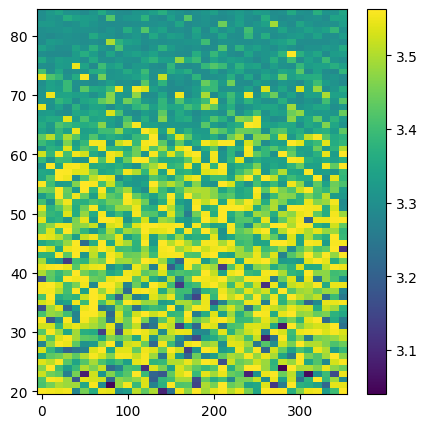

In [24]:
AZ,ALT =np.meshgrid(frb_az,frb_alt)
plt.figure(figsize=(5,5))
plt.pcolormesh(AZ,ALT,log_Area)
plt.colorbar()
plt.savefig("figures/area.png")
plt.show()

Comprehension Questions

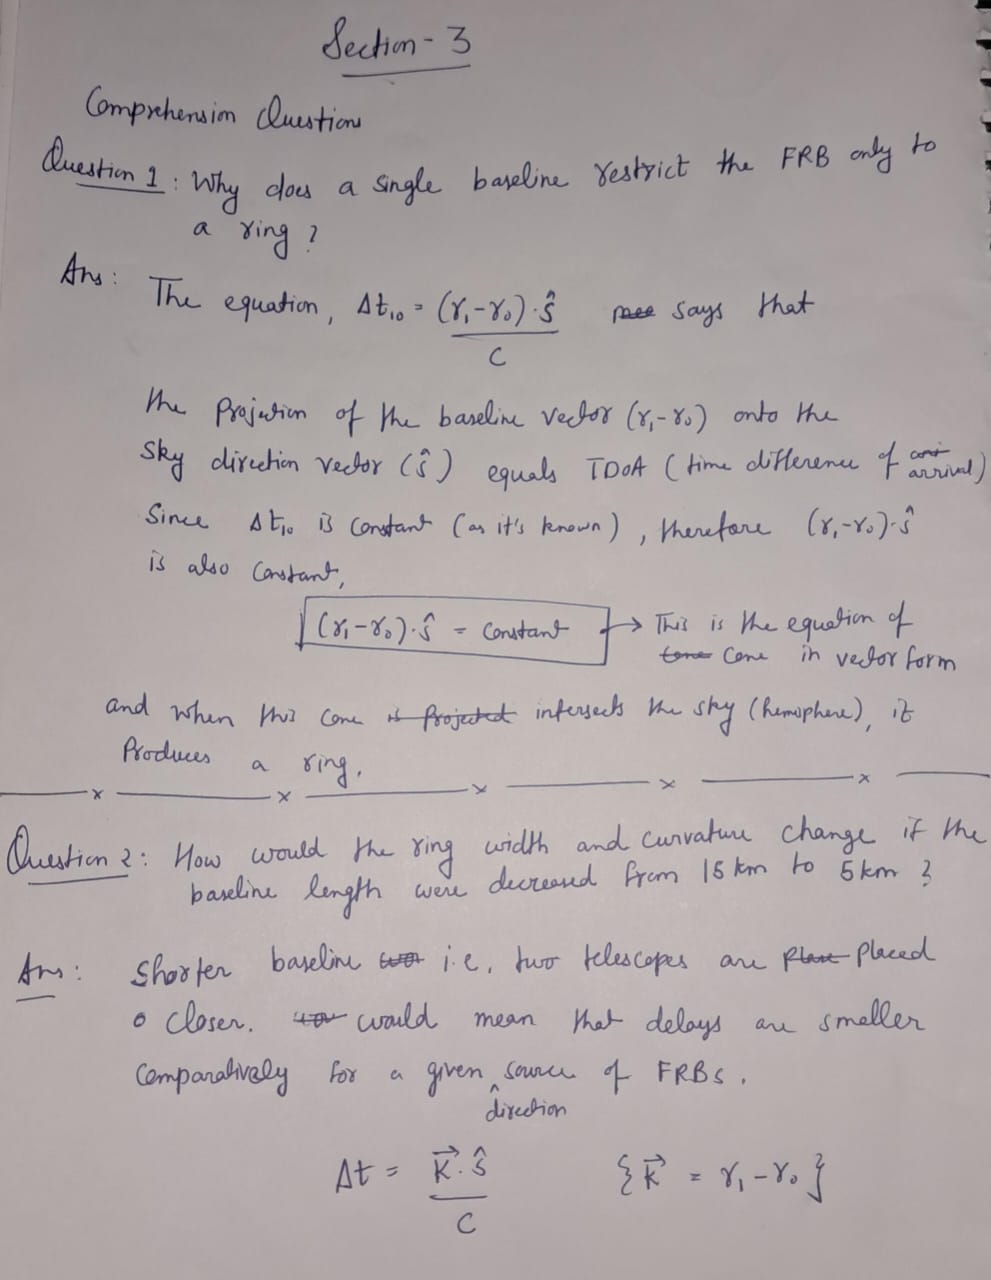

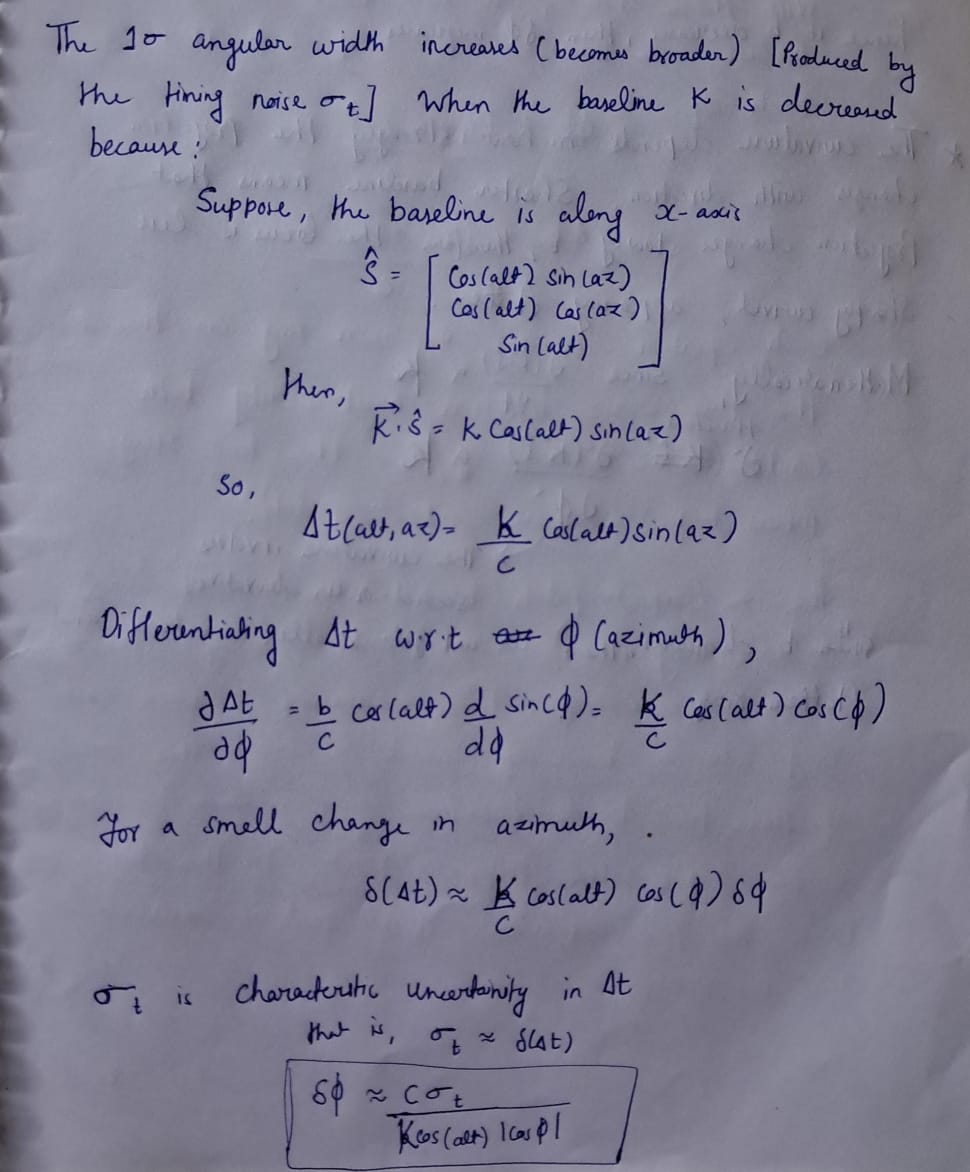

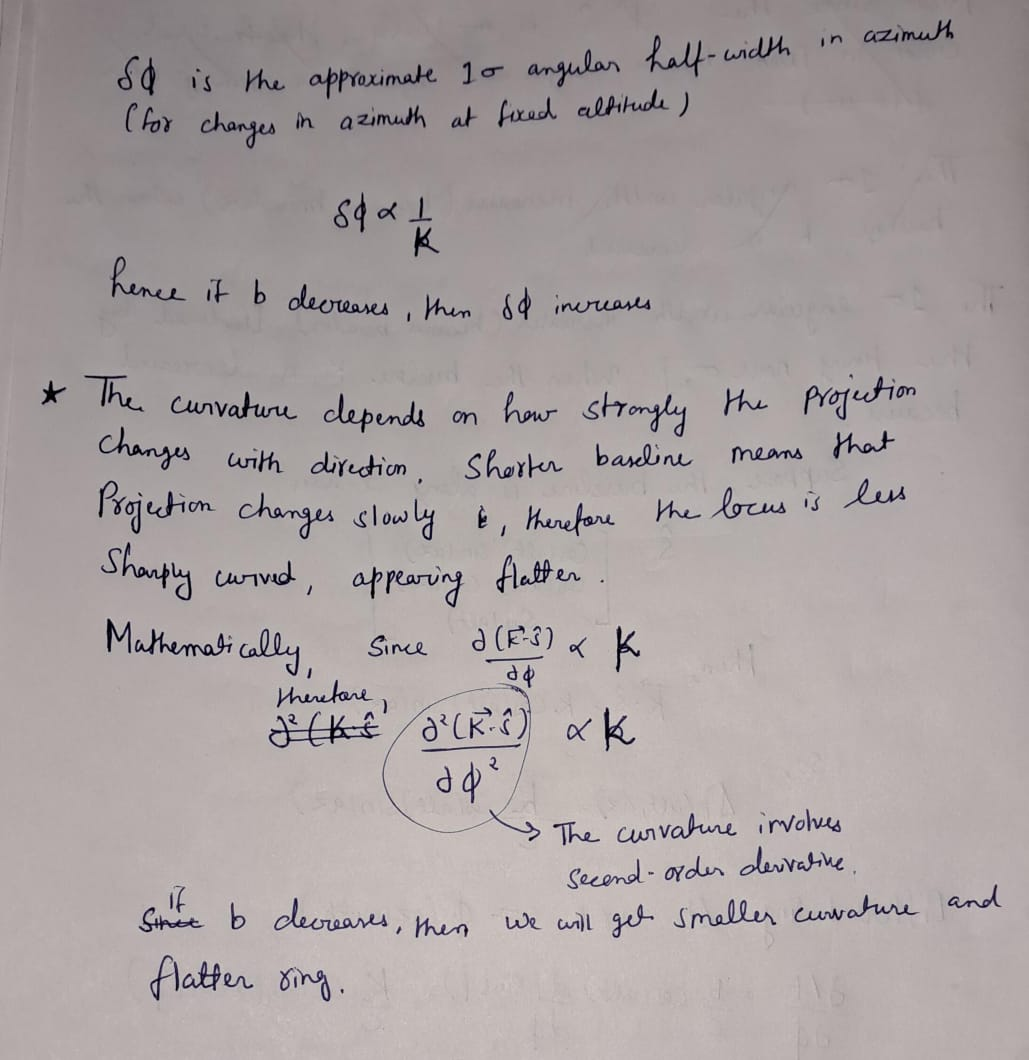

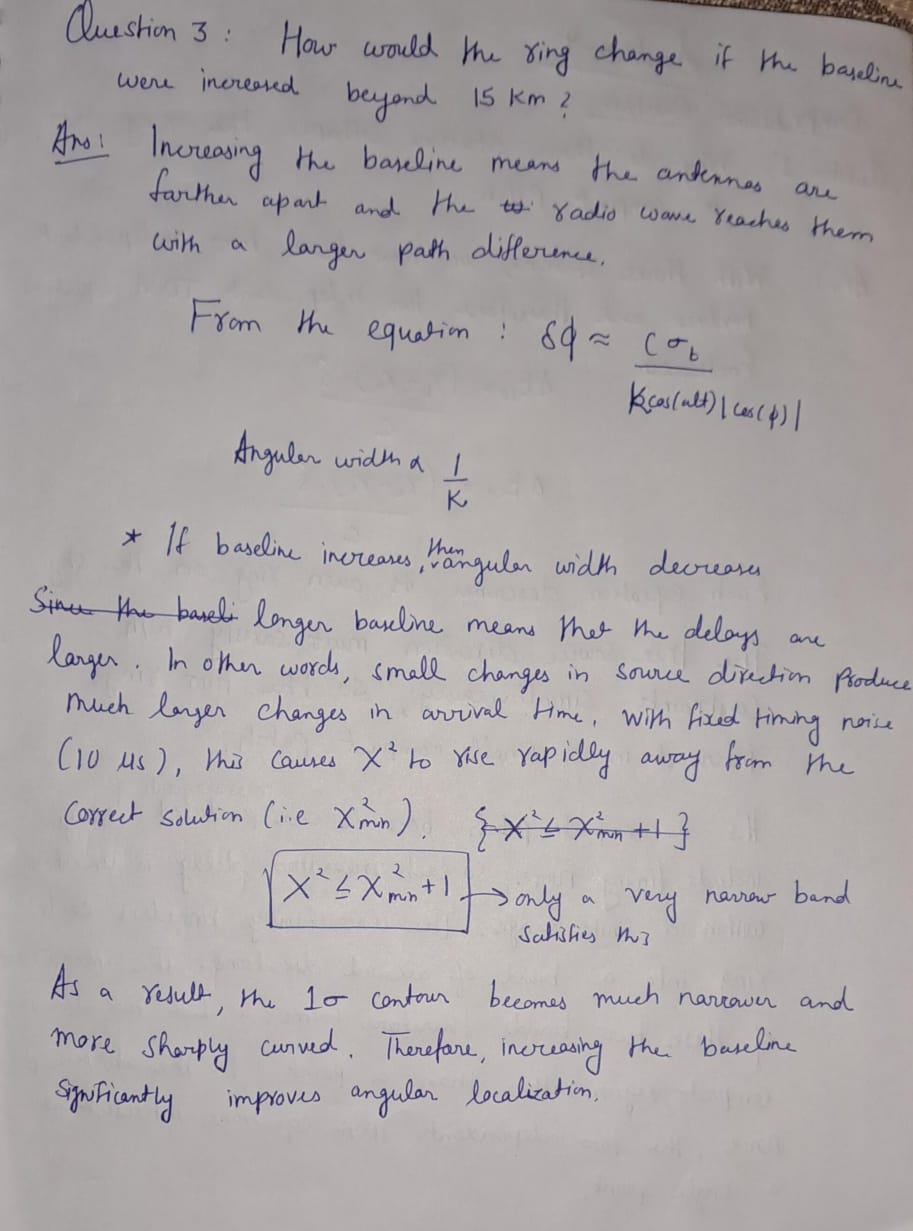

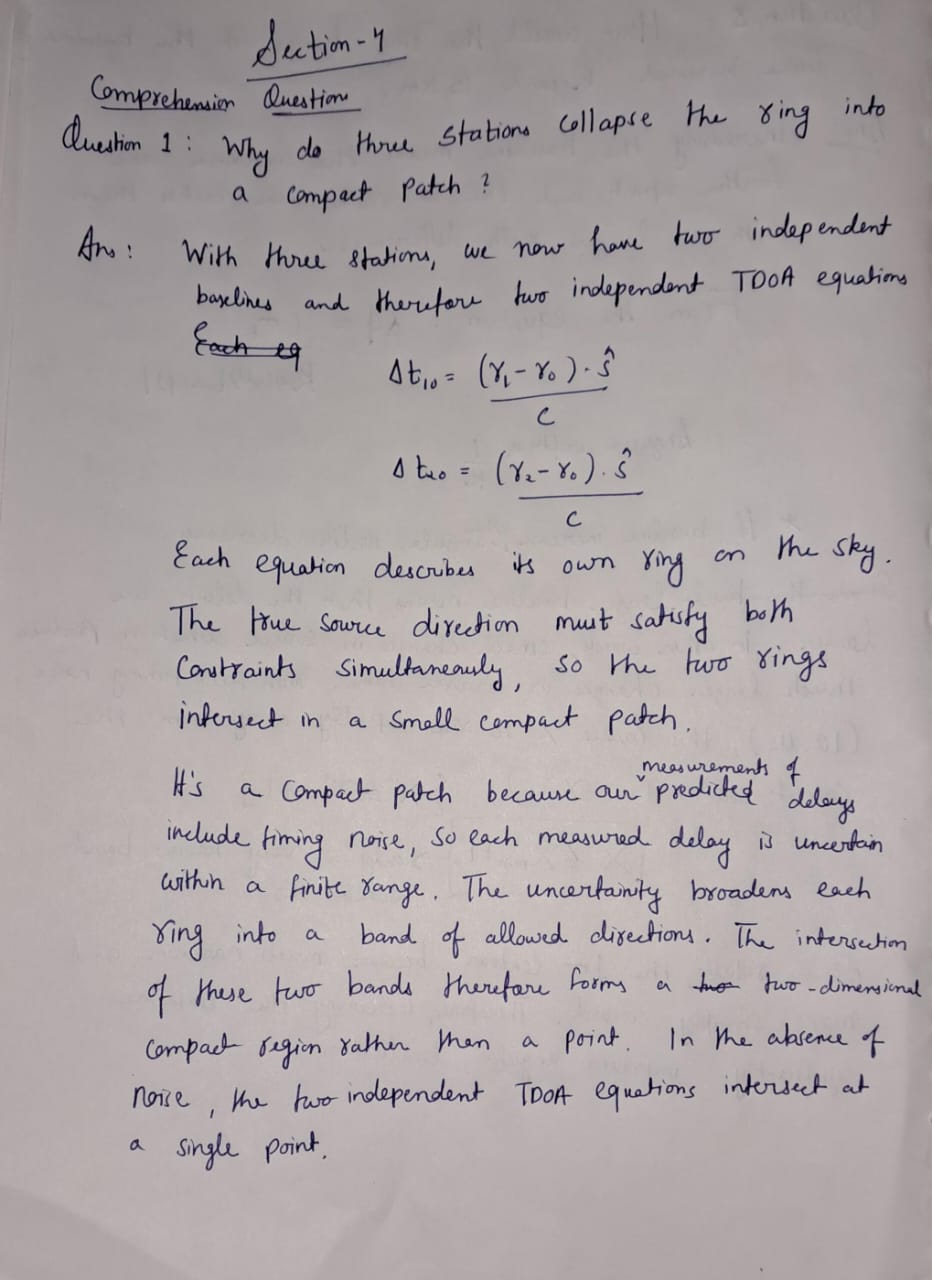

Question 2: How does the shape of this patch depend on the geometry of the triangle formed by the stations?

Answer: To see how does the shape of the localization patch depend on the geometry of the triangle formed by the stations, we repeated the localization analysis for two antenna configurations while keeping the source position and timing noise fixed. it can be seen that a wide, non-colinear right angle, station triangle produces a compact localization patch, whereas a thin, nearly colinear triangle yields an elongated localization area and the 1σ contour stretches, leading to a larger localization area and less precise localization region. This directly demonstrates that the geometry of the station triangle determines the shape and precision of the localization.

This happens because,If the stations form a well-spread, non-colinear triangle, the baselines provide independent timing constraints in different directions on the sky. This causes the χ² surface to rise steeply in all directions away from the minimum, producing a small localization patch. In contrast, if the triangle is skinny or nearly colinear, the baselines constrain similar directions, leaving one angular dimension weakly constrained. This results in elongated   localization patches with larger area. The localization patch is compact only when the baselines constrain the sky in independent directions(i.e When the directions are perpendicular) .

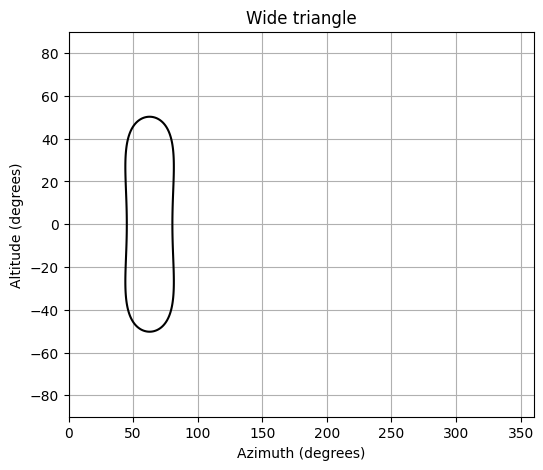

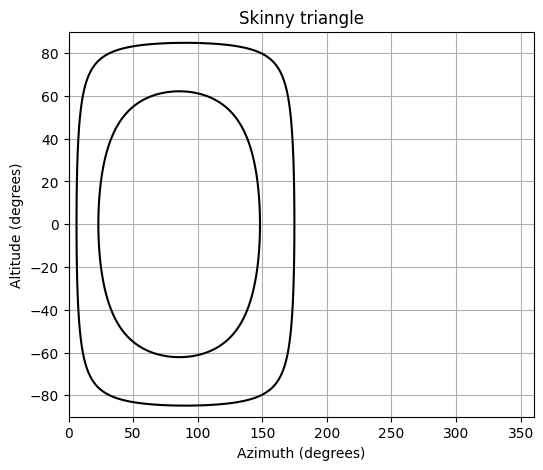

In [28]:
import numpy as np
import matplotlib.pyplot as plt

 
def altaz_to_unit_vector(Az, Alt):
    alt = np.radians(Alt)
    az  = np.radians(Az)
    x = np.cos(alt) * np.sin(az)
    y = np.cos(alt) * np.cos(az)
    z = np.sin(alt)
    return np.array([x, y, z])

c = 3e8
sigma_t = 10e-6
  
true_alt = 45
true_az  = 45
s_true = altaz_to_unit_vector(true_az, true_alt)

 
tel0 = np.array([0.0, 0.0, 0.0])

cases = {"Wide triangle": (np.array([15e3, 0, 0]),np.array([0, 15e3, 0])),"Skinny triangle": (np.array([15e3, 0, 0]),np.array([14e3, 1e3, 0]) )}
  
alt_grid = np.arange(-90, 90, 0.5)
az_grid  = np.arange(0, 360, 0.5)

AZ, ALT = np.meshgrid(az_grid, alt_grid)

 
for name, (tel1, tel2) in cases.items():

    b10 = tel1 - tel0
    b20 = tel2 - tel0

     
    tdoa1 = np.dot(b10, s_true) / c + np.random.normal(0, sigma_t)
    tdoa2 = np.dot(b20, s_true) / c + np.random.normal(0, sigma_t)

    X2 = np.zeros((alt_grid.size, az_grid.size))

    for i, alt in enumerate(alt_grid):
        for j, az in enumerate(az_grid):
            s = altaz_to_unit_vector(az, alt)
            tdoa1_pred = np.dot(b10, s) / c
            tdoa2_pred = np.dot(b20, s) / c

            X2[i, j] = ((tdoa1_pred - tdoa1)**2 +(tdoa2_pred - tdoa2)**2) / sigma_t**2

    deltaX2 = X2 - X2.min()

     
    plt.figure(figsize=(6, 5))
    plt.contour(AZ, ALT, deltaX2, levels=[2.3], colors='black')
    plt.xlabel("Azimuth (degrees)")
    plt.ylabel("Altitude (degrees)")
    plt.title(name)
    plt.xlim(0, 360)
    plt.ylim(-90, 90)
    plt.grid(True)
    plt.savefig("wide triangle.png")
    plt.show()

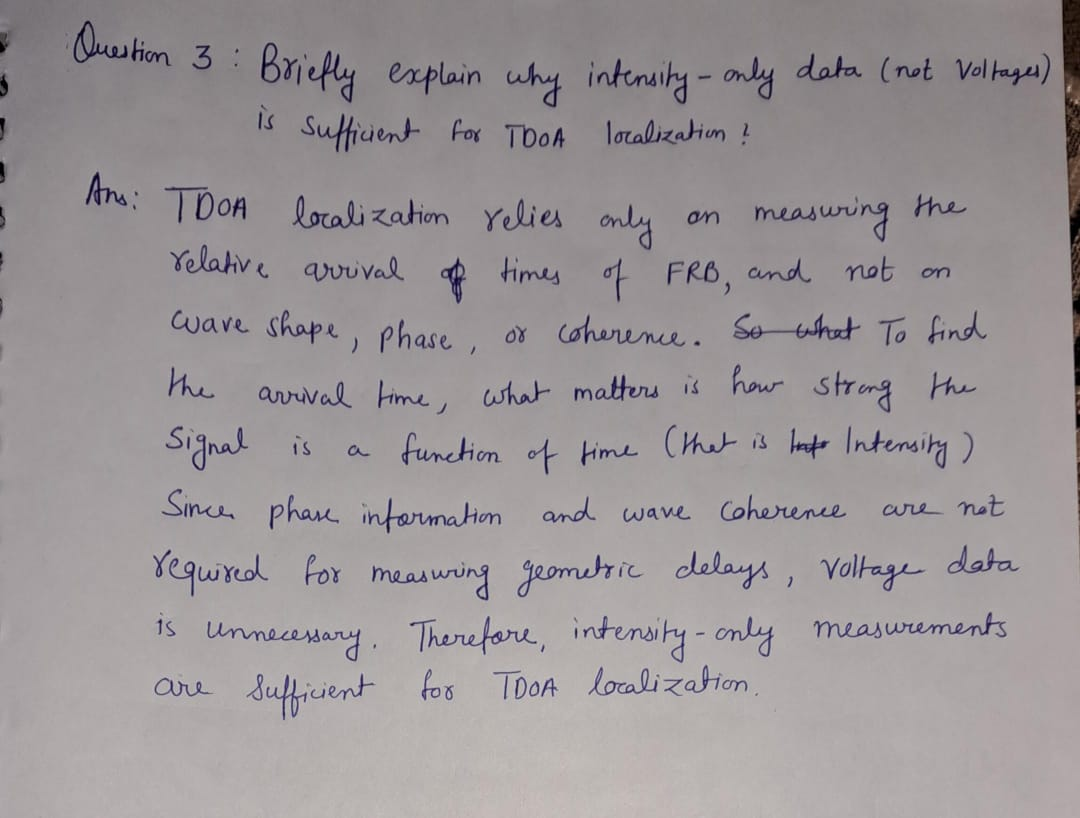

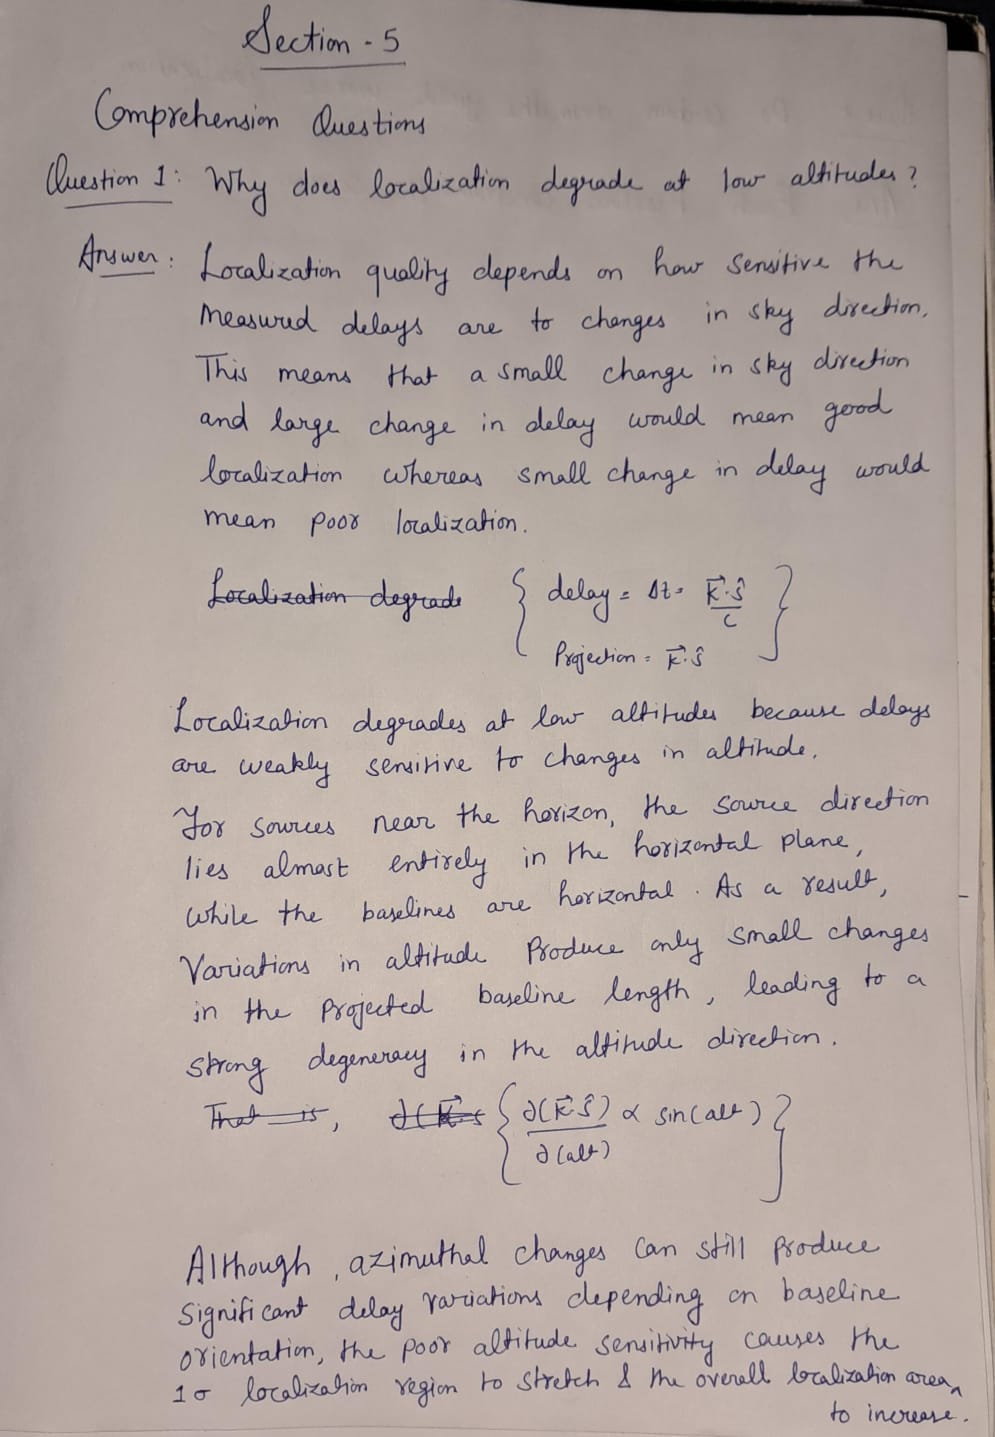

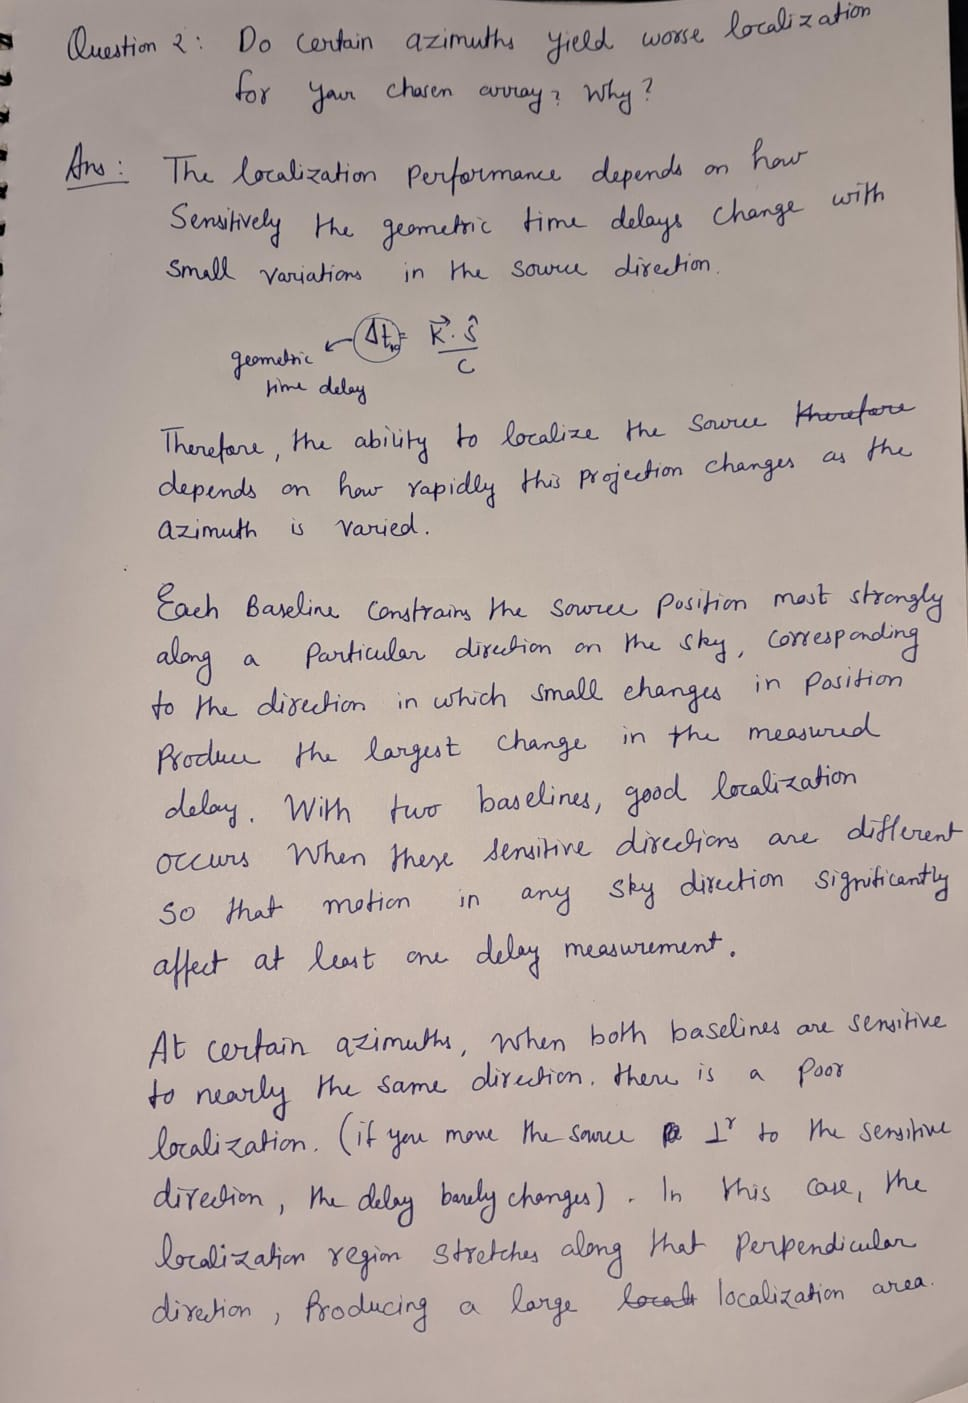

Conclusion:
Using the method of TDOA we can localize Fast Radio Bursts accurately. Using 2 antennas gives us a cone in the sky where FRB may be present. Having 3 Antennas yields better localization compared to 2 antennas as we get two cones and hence their intersection is a smaller area compared to one cone. Using more antennas will improve loclaization further. Localization is better and consistent for FRBs assumed at higher altitudes compared to lower altitudes. Apart for the theoretical knowledge of TDOA method we also learnt about Gaussian distribution and how to genertae Gaussian distribution values using numpy. We learnt about libraries like numpy,matplotlib and healpy. We learnt about HEALPix pixels and used it for better results.